# CELDA 1 — Carga del dataset procesado y configuración de librerías

Cargamos el dataset procesado y configuramos las librerías necesarias
para el entrenamiento de modelos predictivos.

In [1]:
# =============================================================================
# CELDA 1 — Carga del dataset procesado
# =============================================================================

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

plt.style.use('seaborn-v0_8-darkgrid')
sns.set(font_scale=1.2)
warnings.filterwarnings('ignore')

# agregar src al path
sys.path.append(os.path.join('..', 'src'))

import data_collection as dc
import preprocessing as pp
import feature_engineering as fe
import event_study as es
import models as mod
import evaluation as ev
import clustering as cl

print("Módulos del proyecto cargados correctamente.")

# =============================================================================
# Cargar retornos imputados (CSV que sí existe)
# =============================================================================

ruta_retornos = os.path.join('data', 'processed', 'retornos_imputados.csv')

if os.path.exists(ruta_retornos):

    df = pd.read_csv(ruta_retornos, index_col=0, parse_dates=True)

    print("\nRetornos imputados cargados correctamente")
    print(f"Shape: {df.shape}")
    print("Columnas:", list(df.columns))

else:
    print("\n⚠️ No se encontró retornos_imputados.csv")


# =============================================================================
# Cargar retornos diarios
# =============================================================================

ruta_retornos_d = os.path.join('data', 'processed', 'retornos_diarios.csv')

if os.path.exists(ruta_retornos_d):

    df_retornos = pd.read_csv(
        ruta_retornos_d,
        index_col=0,
        parse_dates=True
    )

    print("\nRetornos diarios cargados correctamente")
    print(f"Shape: {df_retornos.shape}")

else:
    print("\n⚠️ No se encontró retornos_diarios.csv")

Módulos del proyecto cargados correctamente.

Retornos imputados cargados correctamente
Shape: (1326, 11)
Columnas: ['SP500', 'VIX', 'BRENT', 'WTI', 'BOVESPA', 'MERVAL', 'USD_COP', 'GOLD', 'COPPER', 'EXXON', 'CHEVRON']

Retornos diarios cargados correctamente
Shape: (1326, 11)


# CELDA 2 — Event Study: cálculo de AR y CAR para todos los activos

Calculamos los retornos anormales (AR) y retornos anormales acumulados (CAR)
para todos los activos financieros usando el modelo de mercado.

Retornos diarios cargados: (1326, 11)

Calculando retornos anormales para todos los activos...

CALCULANDO RETORNOS ANORMALES PARA TODOS LOS ACTIVOS

Procesando VIX...

Modelo de mercado para VIX:
- Alpha (α): 0.006455
- Beta (β): -7.729818
- R²: 0.637717
- Observaciones: 144
- CAR[-5,-1]: 0.001695
- CAR[0,+5]: 0.107621
- CAR[+6,+20]: -0.099352

Procesando BRENT...

Modelo de mercado para BRENT:
- Alpha (α): 0.000893
- Beta (β): -0.146814
- R²: 0.003151
- Observaciones: 144
- CAR[-5,-1]: 0.018386
- CAR[0,+5]: 0.017974
- CAR[+6,+20]: 0.043513

Procesando WTI...

Modelo de mercado para WTI:
- Alpha (α): 0.000972
- Beta (β): -0.176827
- R²: 0.004057
- Observaciones: 144
- CAR[-5,-1]: 0.018295
- CAR[0,+5]: 0.005376
- CAR[+6,+20]: 0.035486

Procesando BOVESPA...

Modelo de mercado para BOVESPA:
- Alpha (α): 0.000813
- Beta (β): 0.435340
- R²: 0.103231
- Observaciones: 144
- CAR[-5,-1]: 0.001912
- CAR[0,+5]: 0.007594
- CAR[+6,+20]: 0.068289

Procesando MERVAL...

Modelo de mercado para MERVA

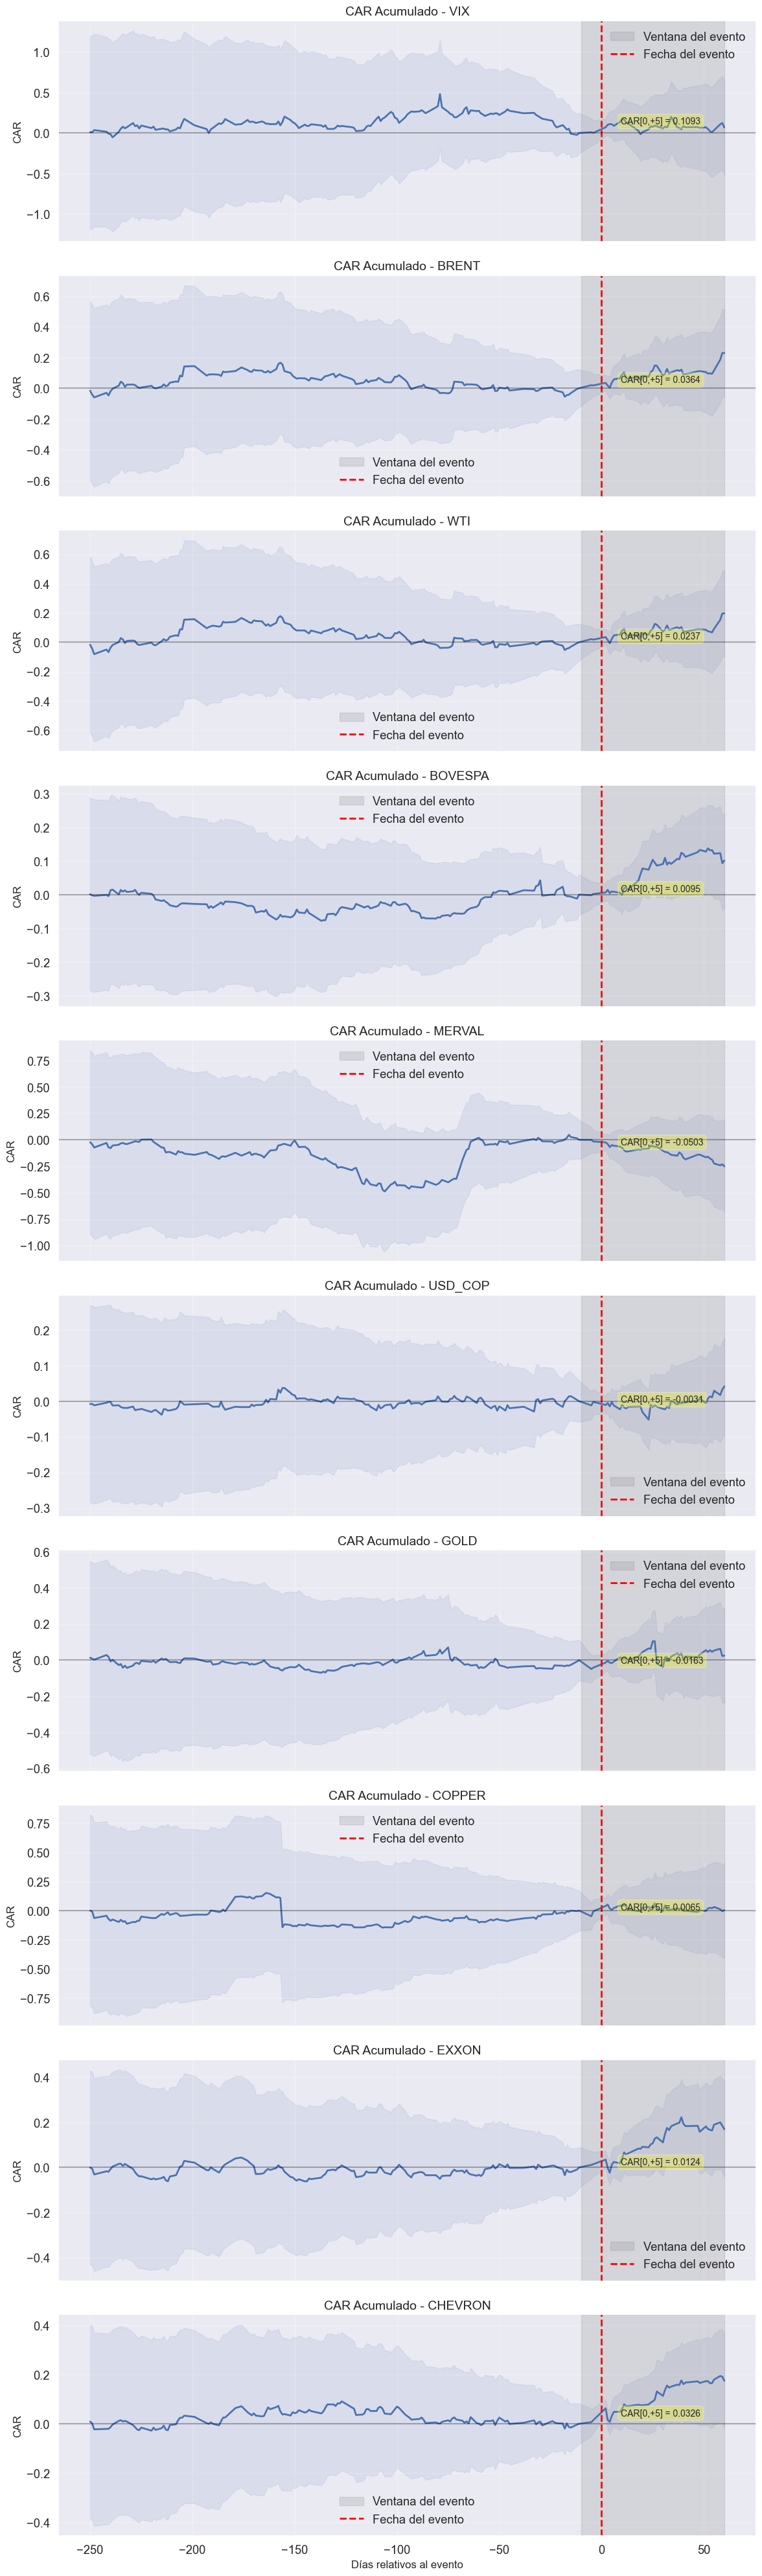


Retornos anormales guardados en: data\processed\retornos_anormales.csv


In [2]:
# =============================================================================
# CELDA 2 — Event Study: cálculo de AR y CAR para todos los activos
# =============================================================================

# Cargar retornos diarios (ruta correcta dentro de notebooks)
ruta_retornos = os.path.join('data', 'processed', 'retornos_diarios.csv')

df_retornos = pd.read_csv(
    ruta_retornos,
    index_col=0,
    parse_dates=True
)

print("Retornos diarios cargados:", df_retornos.shape)

# -----------------------------------------------------------------------------
# Calcular retornos anormales
# -----------------------------------------------------------------------------

print("\nCalculando retornos anormales para todos los activos...")
df_ar = es.calcular_ar_todos_activos(df_retornos, dc.EVENT_DATE)

# -----------------------------------------------------------------------------
# Mostrar α, β, R² del modelo de mercado
# -----------------------------------------------------------------------------

print("\nParámetros del modelo de mercado por activo:")

for activo in df_retornos.columns:

    if activo != 'SP500':

        params = es.estimar_modelo_mercado(
            df_retornos,
            activo,
            'SP500',
            es.VENTANA_ESTIMACION_INICIO,
            es.VENTANA_ESTIMACION_FIN,
            dc.EVENT_DATE
        )

        print(f"\n{activo}")
        print(f"α (alpha): {params['alpha']:.6f}")
        print(f"β (beta): {params['beta']:.6f}")
        print(f"R²: {params['r2']:.6f}")

# -----------------------------------------------------------------------------
# Graficar CAR acumulado
# -----------------------------------------------------------------------------

print("\nGenerando gráficos de CAR acumulados...")
fig = es.graficar_car_activos(df_ar, dc.EVENT_DATE)
plt.show()

# -----------------------------------------------------------------------------
# Guardar retornos anormales
# -----------------------------------------------------------------------------

ruta_ar = os.path.join('data', 'processed', 'retornos_anormales.csv')

df_ar.to_csv(ruta_ar)

print(f"\nRetornos anormales guardados en: {ruta_ar}")

# CELDA 3 — Creación de la variable objetivo

Creamos variables objetivo binarias basadas en los retornos anormales:
- target = 1 si AR > 0 (retorno anormal positivo)
- target = 0 si AR ≤ 0 (retorno anormal negativo)

Creando variables objetivo...

CREANDO VARIABLES OBJETIVO

Distribución para VIX:
- Clase 1 (AR > 0): 608 (45.85%)
- Clase 0 (AR ≤ 0): 718 (54.15%)

Distribución para BRENT:
- Clase 1 (AR > 0): 685 (51.66%)
- Clase 0 (AR ≤ 0): 641 (48.34%)

Distribución para WTI:
- Clase 1 (AR > 0): 688 (51.89%)
- Clase 0 (AR ≤ 0): 638 (48.11%)

Distribución para BOVESPA:
- Clase 1 (AR > 0): 634 (47.81%)
- Clase 0 (AR ≤ 0): 692 (52.19%)

Distribución para MERVAL:
- Clase 1 (AR > 0): 672 (50.68%)
- Clase 0 (AR ≤ 0): 654 (49.32%)

Distribución para USD_COP:
- Clase 1 (AR > 0): 708 (53.39%)
- Clase 0 (AR ≤ 0): 618 (46.61%)

Distribución para GOLD:
- Clase 1 (AR > 0): 615 (46.38%)
- Clase 0 (AR ≤ 0): 711 (53.62%)

Distribución para COPPER:
- Clase 1 (AR > 0): 653 (49.25%)
- Clase 0 (AR ≤ 0): 673 (50.75%)

Distribución para EXXON:
- Clase 1 (AR > 0): 673 (50.75%)
- Clase 0 (AR ≤ 0): 653 (49.25%)

Distribución para CHEVRON:
- Clase 1 (AR > 0): 675 (50.90%)
- Clase 0 (AR ≤ 0): 651 (49.10%)

Distribución de cl

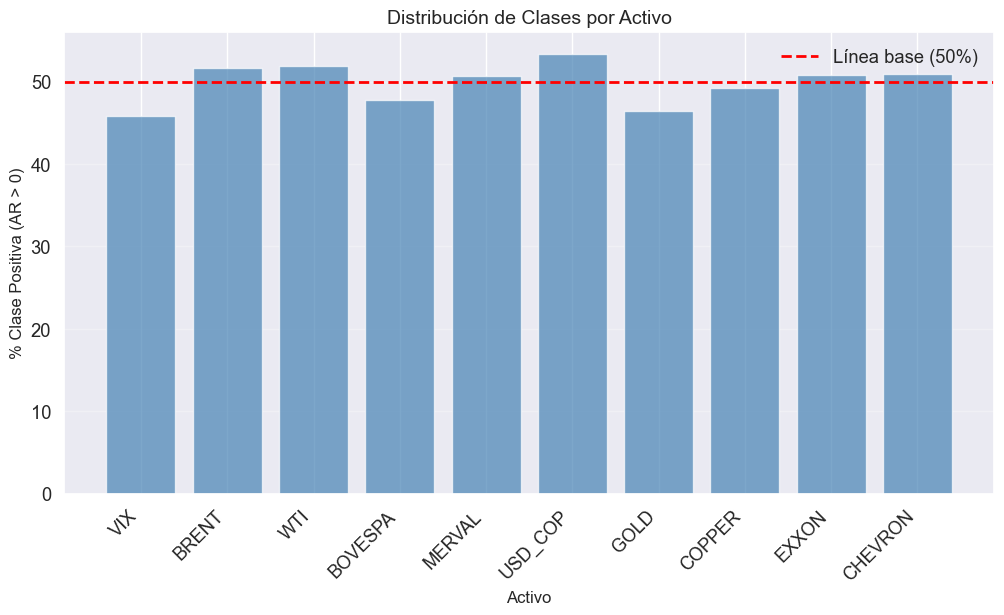


Gráfico de distribución de clases guardado en: ..\data\processed\graficos\distribucion_clases.png

Conclusión sobre balanceo de clases:
  VIX: 45.9% - No se requiere balanceo
  BRENT: 51.7% - No se requiere balanceo
  WTI: 51.9% - No se requiere balanceo
  BOVESPA: 47.8% - No se requiere balanceo
  MERVAL: 50.7% - No se requiere balanceo
  USD_COP: 53.4% - No se requiere balanceo
  GOLD: 46.4% - No se requiere balanceo
  COPPER: 49.2% - No se requiere balanceo
  EXXON: 50.8% - No se requiere balanceo
  CHEVRON: 50.9% - No se requiere balanceo

Dataset final para modelamiento:
Shape: (1326, 21)

Columnas target añadidas:
['target_VIX', 'target_BRENT', 'target_WTI', 'target_BOVESPA', 'target_MERVAL', 'target_USD_COP', 'target_GOLD', 'target_COPPER', 'target_EXXON', 'target_CHEVRON']


In [3]:
# =============================================================================
# CELDA 3 — Creación de la variable objetivo
# =============================================================================

# Crear variable objetivo
print("Creando variables objetivo...")
df_target = es.crear_variable_objetivo(df_ar)

# Mostrar distribución de clases
print("\nDistribución de clases por activo:")
for columna in df_target.columns:
    activo = columna.replace('target_', '')
    n_positivos = df_target[columna].sum()
    n_negativos = len(df_target) - n_positivos
    pct_positivos = n_positivos / len(df_target) * 100
    
    print(f"\n{activo}:")
    print(f"  Clase 1 (AR > 0): {n_positivos} ({pct_positivos:.2f}%)")
    print(f"  Clase 0 (AR ≤ 0): {n_negativos} ({100-pct_positivos:.2f}%)")

# Gráfico de barras con el desbalance de clases
plt.figure(figsize=(12, 6))

activos = [col.replace('target_', '') for col in df_target.columns]
pct_positivos = [df_target[f'target_{activo}'].mean() * 100 for activo in activos]

plt.bar(activos, pct_positivos, color='steelblue', alpha=0.7)
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Línea base (50%)')

plt.title('Distribución de Clases por Activo', fontsize=14)
plt.xlabel('Activo', fontsize=12)
plt.ylabel('% Clase Positiva (AR > 0)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

# Guardar gráfico
ruta_guardado = os.path.join('..', 'data', 'processed', 'graficos', 'distribucion_clases.png')
plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico de distribución de clases guardado en: {ruta_guardado}")

# Concluir si se requiere balanceo
print("\nConclusión sobre balanceo de clases:")
for activo in activos:
    pct = df_target[f'target_{activo}'].mean() * 100
    if pct < 40 or pct > 60:
        print(f"  {activo}: {pct:.1f}% - Se requiere balanceo (SMOTE)")
    else:
        print(f"  {activo}: {pct:.1f}% - No se requiere balanceo")

# =============================================================================
# UNIR FEATURES Y TARGET
# =============================================================================

df = df.join(df_target)

print("\nDataset final para modelamiento:")
print("Shape:", df.shape)

print("\nColumnas target añadidas:")
print([col for col in df.columns if col.startswith('target_')])

# CELDA 4 — División 70/30 y SMOTE si aplica

Dividimos los datos en 70% entrenamiento y 30% prueba con estratificación,
y aplicamos SMOTE si es necesario para balancear las clases.

In [5]:
# =============================================================================
# CELDA 4 — División 70/30 y corrección de leakage temporal
# =============================================================================

# Seleccionar un activo
activo_objetivo = 'BRENT'
target_col = f'target_{activo_objetivo}'

print(f"Entrenando modelo para {activo_objetivo}...")

# -----------------------------------------------------------------------------
# Preparar features y target
# -----------------------------------------------------------------------------

columnas_excluir = [col for col in df.columns if col.startswith('target_')] + \
                   [col for col in df.columns if col.endswith('_sector')]

X = df.drop(columnas_excluir, axis=1)
y = df[target_col]

# -----------------------------------------------------------------------------
# CORRECCIÓN DE LEAKAGE TEMPORAL
# usar información del día anterior
# -----------------------------------------------------------------------------

X = X.shift(1)

# eliminar fila inicial con NaN
X = X.dropna()

# alinear target con X
y = y.loc[X.index]

print("\nShapes después del shift temporal:")
print("X:", X.shape)
print("y:", y.shape)

# -----------------------------------------------------------------------------
# Dividir datos
# -----------------------------------------------------------------------------

X_train, X_test, y_train, y_test = mod.dividir_datos(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# -----------------------------------------------------------------------------
# Aplicar SMOTE si hay desbalance
# -----------------------------------------------------------------------------

X_train_bal, y_train_bal = mod.aplicar_smote_si_necesario(
    X_train,
    y_train,
    umbral_desbalance=0.40
)

# -----------------------------------------------------------------------------
# Estandarizar
# -----------------------------------------------------------------------------

X_train_std, scaler = pp.estandarizar_zscore(X_train_bal)

X_test_std = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

print("\nDatos preparados para modelamiento.")

Entrenando modelo para BRENT...

Shapes después del shift temporal:
X: (1325, 11)
y: (1325,)

DIVISIÓN DE DATOS (TEST_SIZE=0.3)

Shape de X_train: (927, 11)
Shape de X_test: (398, 11)

Distribución de clases en entrenamiento:
target_BRENT
1    51.67
0    48.33
Name: proportion, dtype: float64

Distribución de clases en prueba:
target_BRENT
1    51.51
0    48.49
Name: proportion, dtype: float64

EVALUACIÓN DE BALANCE DE CLASES (UMBRAL=0.4)

Proporción de la clase minoritaria (0): 0.4833
Proporción >= 0.4, no se requiere balanceo

ESTANDARIZACIÓN Z-SCORE

Estadísticas antes de estandarización:
       SP500     VIX   BRENT     WTI  BOVESPA  MERVAL  USD_COP    GOLD  \
mean  0.0005 -0.0034 -0.0002  0.0005   0.0002  0.0021   0.0001  0.0004   
std   0.0126  0.0754  0.0262  0.0307   0.0149  0.0263   0.0099  0.0107   

      COPPER   EXXON  CHEVRON  
mean  0.0002  0.0005   0.0001  
std   0.0185  0.0200   0.0203  

Estadísticas después de estandarización:
       SP500     VIX   BRENT     WTI  BO

In [6]:
# =============================================================================
# CREAR DATASET DE MODELAMIENTO
# =============================================================================

import os

print("Creando dataset de modelamiento...")

# -------------------------------------------------------------------
# Verificar que exista el dataframe final
# -------------------------------------------------------------------

print("Shape del dataframe:", df.shape)
print("Columnas:", len(df.columns))

# -------------------------------------------------------------------
# Crear carpeta si no existe
# -------------------------------------------------------------------

ruta_guardado = os.path.join('..', 'data', 'processed')
os.makedirs(ruta_guardado, exist_ok=True)

# -------------------------------------------------------------------
# Guardar dataset
# -------------------------------------------------------------------

ruta_dataset = os.path.join(ruta_guardado, 'dataset_modelamiento.csv')

df.to_csv(ruta_dataset)

print("\nDataset guardado correctamente en:")
print(ruta_dataset)

# Verificar
print("\nVerificación:")
print(os.path.exists(ruta_dataset))

Creando dataset de modelamiento...
Shape del dataframe: (1326, 21)
Columnas: 21

Dataset guardado correctamente en:
..\data\processed\dataset_modelamiento.csv

Verificación:
True


# CELDA 5 — Entrenamiento con validación cruzada 10-fold

Entrenamos los 7 modelos con validación cruzada estratificada de 10 folds
y calculamos métricas de rendimiento para cada modelo.

Entrenando modelos con validación cruzada...

ENTRENAMIENTO CON VALIDACIÓN CRUZADA (10-FOLD)

Entrenando arbol_decision...
  Fold 1: AUC=0.5375, F1=0.5474, Acc=0.5376
  Fold 2: AUC=0.4854, F1=0.4667, Acc=0.4839
  Fold 3: AUC=0.5819, F1=0.5714, Acc=0.5806
  Fold 4: AUC=0.5382, F1=0.5376, Acc=0.5376
  Fold 5: AUC=0.4819, F1=0.5200, Acc=0.4839
  Fold 6: AUC=0.5049, F1=0.5208, Acc=0.5054
  Fold 7: AUC=0.4757, F1=0.4368, Acc=0.4731
  Fold 8: AUC=0.4475, F1=0.4000, Acc=0.4457
  Fold 9: AUC=0.4451, F1=0.4632, Acc=0.4457
  Fold 10: AUC=0.4650, F1=0.5051, Acc=0.4674

Entrenando knn...
  Fold 1: AUC=0.4822, F1=0.5714, Acc=0.5161
  Fold 2: AUC=0.5317, F1=0.5000, Acc=0.5054
  Fold 3: AUC=0.5648, F1=0.4944, Acc=0.5161
  Fold 4: AUC=0.4498, F1=0.4632, Acc=0.4516
  Fold 5: AUC=0.4813, F1=0.5306, Acc=0.5054
  Fold 6: AUC=0.5204, F1=0.5600, Acc=0.5269
  Fold 7: AUC=0.5340, F1=0.5567, Acc=0.5376
  Fold 8: AUC=0.4719, F1=0.4783, Acc=0.4783
  Fold 9: AUC=0.4905, F1=0.4842, Acc=0.4674
  Fold 10: AUC=0.4723

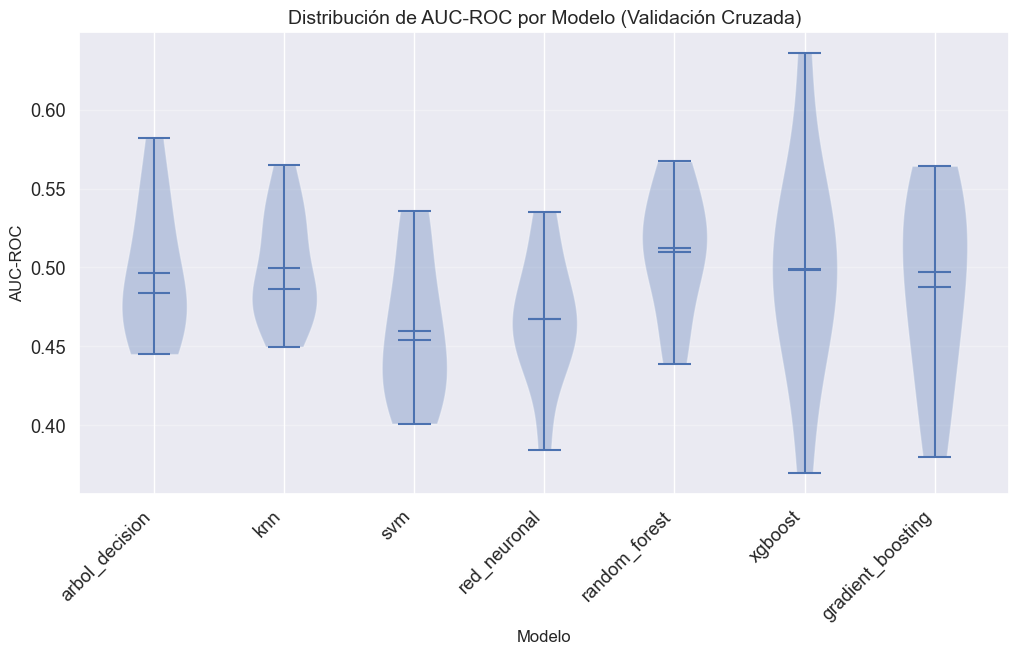


Gráfico de violin plot guardado en: ..\data\processed\graficos\violin_auc_roc.png


In [7]:
# =============================================================================
# CELDA 5 — Entrenamiento con validación cruzada 10-fold
# =============================================================================

# Entrenar con validación cruzada
print("Entrenando modelos con validación cruzada...")
resultados_cv = mod.entrenar_con_validacion_cruzada(X_train_std, y_train_bal, n_folds=10)

# Crear violin plot con distribución de AUC-ROC por modelo
plt.figure(figsize=(12, 6))

# Preparar datos para violin plot
datos_violin = []
etiquetas = []

for nombre_modelo, res in resultados_cv.items():
    datos_violin.append(res['auc'])
    etiquetas.append(nombre_modelo)

# Crear violin plot
plt.violinplot(datos_violin, showmeans=True, showmedians=True)
plt.xticks(range(1, len(etiquetas) + 1), etiquetas, rotation=45, ha='right')

# Configurar gráfico
plt.title('Distribución de AUC-ROC por Modelo (Validación Cruzada)', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('AUC-ROC', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)

# Guardar gráfico
ruta_guardado = os.path.join('..', 'data', 'processed', 'graficos', 'violin_auc_roc.png')
plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico de violin plot guardado en: {ruta_guardado}")

# CELDA 6 — ANOVA + Tukey

Aplicamos ANOVA para comparar los modelos y, si es significativo,
usamos el test de Tukey HSD para identificar diferencias específicas.

In [8]:
# =============================================================================
# CELDA 6 — Comparación de modelos (ANOVA + Tukey HSD)
# =============================================================================

from scipy import stats
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("Comparando modelos con ANOVA + Tukey HSD...")

# -----------------------------------------------------------------------------
# Preparar datos: usar AUC de cada fold (resultados_cv[modelo]['auc'])
# -----------------------------------------------------------------------------

modelos = list(resultados_cv.keys())

# Extraer todos los AUC por fold de cada modelo
auc_por_modelo = []
nombres_modelos = []

for nombre_modelo in modelos:
    aucs = resultados_cv[nombre_modelo]['auc']  # Lista de 10 valores AUC por fold
    auc_por_modelo.extend(aucs)
    nombres_modelos.extend([nombre_modelo] * len(aucs))

df_anova = pd.DataFrame({
    'modelo': nombres_modelos,
    'auc': auc_por_modelo
})

# -----------------------------------------------------------------------------
# ANOVA: Test F para comparar medias entre los 7 modelos
# -----------------------------------------------------------------------------

grupos = [df_anova.loc[df_anova['modelo'] == modelo, 'auc'].values for modelo in modelos]
f_stat, p_valor = stats.f_oneway(*grupos)

print("\n" + "="*80)
print("RESULTADOS ANOVA")
print("="*80)
print(f"F-estadístico: {f_stat:.4f}")
print(f"p-valor: {p_valor:.4f}")

if p_valor < 0.05:
    print("\nInterpretación: El p-valor es menor que 0.05, por lo que existen diferencias"
          "estadísticamente significativas entre al menos algunos de los 7 modelos."
          "Se procede a aplicar el test de Tukey HSD para identificar qué pares"
          "de modelos son diferentes.")
else:
    print("\nInterpretación: El p-valor es mayor o igual a 0.05, por lo que no hay"
          "evidencia suficiente para afirmar que existan diferencias significativas"
          "entre los modelos en términos de AUC-ROC.")

# -----------------------------------------------------------------------------
# Tukey HSD: comparaciones pairwise (solo si ANOVA es significativo)
# -----------------------------------------------------------------------------

if p_valor < 0.05:
    print("\n" + "="*80)
    print("TEST DE TUKEY HSD (comparaciones múltiples)")
    print("="*80)

    tukey = pairwise_tukeyhsd(
        endog=df_anova['auc'],
        groups=df_anova['modelo'],
        alpha=0.05
    )
    print(tukey)
    
    # Identificar mejores modelos basados en medias de AUC
    print("\n" + "="*80)
    print("MEDIAS DE AUC-ROC POR MODELO")
    print("="*80)
    medias_auc = df_anova.groupby('modelo')['auc'].mean().sort_values(ascending=False)
    print(medias_auc)
    
    # Seleccionar los 3 mejores basándose en las medias de AUC
    mejores_3 = medias_auc.head(3).index.tolist()
    
    print("\n" + "="*80)
    print("LOS 3 MEJORES MODELOS SELECCIONADOS (basado en AUC-ROC promedio)")
    print("="*80)
    for i, modelo in enumerate(mejores_3):
        auc_mean = medias_auc[modelo]
        print(f"  {i+1}. {modelo}: AUC-ROC = {auc_mean:.4f}")
    
    # Asignar para uso en celdas siguientes
    mejores_modelos = mejores_3
else:
    # Si ANOVA no es significativo, seleccionar por simple AUC promedio
    auc_promedios = {nombre: res['auc_mean'] for nombre, res in resultados_cv.items()}
    mejores_3 = sorted(auc_promedios.items(), key=lambda x: x[1], reverse=True)[:3]
    mejores_3 = [nombre for nombre, _ in mejores_3]
    print("\nDado que no hay diferencias significativas, se seleccionan los 3 mejores"
          "por AUC-ROC promedio:")
    for i, modelo in enumerate(mejores_3):
        auc = resultados_cv[modelo]['auc_mean']
        print(f"  {i+1}. {modelo}: AUC-ROC = {auc:.4f}")
    
    mejores_modelos = mejores_3

Comparando modelos con ANOVA + Tukey HSD...

RESULTADOS ANOVA
F-estadístico: 1.3430
p-valor: 0.2517

Interpretación: El p-valor es mayor o igual a 0.05, por lo que no hayevidencia suficiente para afirmar que existan diferencias significativasentre los modelos en términos de AUC-ROC.

Dado que no hay diferencias significativas, se seleccionan los 3 mejorespor AUC-ROC promedio:
  1. random_forest: AUC-ROC = 0.5097
  2. knn: AUC-ROC = 0.4999
  3. xgboost: AUC-ROC = 0.4991


# CELDA 7 — Hiperparametrización de los 3 mejores modelos

Optimizamos los hiperparámetros de los 3 mejores modelos usando
GridSearchCV y BayesSearchCV.

In [9]:
# =============================================================================
# CELDA 7 — Hiperparametrización de los 3 mejores modelos
# =============================================================================

# Hiperparametrizar modelos
print("Optimizando hiperparámetros de los 3 mejores modelos...")
modelos_optimos = mod.hiperparametrizar_modelos(X_train_std, y_train_bal, mejores_modelos)

# Mostrar mejores hiperparámetros
print("\nMejores hiperparámetros por modelo:")
for nombre_modelo, modelo in modelos_optimos.items():
    print(f"\n{nombre_modelo}:")
    print(f"  Parámetros: {modelo.get_params()}")

Optimizando hiperparámetros de los 3 mejores modelos...

OPTIMIZACIÓN DE HIPERPARÁMETROS

Optimizando random_forest...

1. Aplicando GridSearchCV...
  Mejor AUC-ROC: 0.4959
  Mejores parámetros: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}

2. Aplicando BayesSearchCV...
  Mejor AUC-ROC: 0.4947
  Mejores parámetros: OrderedDict([('max_depth', 13), ('max_features', None), ('n_estimators', 126)])

Seleccionando modelo de GridSearchCV (mejor AUC-ROC)
AUC-ROC final: 0.4959
Parámetros finales: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}

Optimizando knn...

1. Aplicando GridSearchCV...
  Mejor AUC-ROC: 0.5119
  Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 3}

2. Aplicando BayesSearchCV...
  Mejor AUC-ROC: 0.5224
  Mejores parámetros: OrderedDict([('metric', 'euclidean'), ('n_neighbors', 2)])

Seleccionando modelo de BayesSearchCV (mejor AUC-ROC)
AUC-ROC final: 0.5224
Parámetros finales: OrderedDict([('metric', 'euclidean'), ('n_neighbors

# CELDA 8 — Evaluación final sobre el 30% de prueba

Evaluamos los 3 modelos optimizados sobre el conjunto de prueba (30%)
y mostramos métricas completas con interpretación en español.


Evaluando random_forest

EVALUACIÓN COMPLETA DEL MODELO: random_forest

MÉTRICAS DE EVALUACIÓN:

1. AUC-ROC: 0.5484
   Interpretación: AUC-ROC de 0.55: el modelo distingue correctamente entre subida y bajada en el 55% de los casos, superando en 5 puntos porcentuales la línea base aleatoria de 0.50.

2. F1-Score: 0.5437
   Interpretación: F1-Score de 0.54: balance adecuado entre no perderse subidas reales y no generar falsas alarmas de subida.

3. Accuracy: 0.5276
   Interpretación: Accuracy de 0.53: el modelo clasificó correctamente el 53% de los días del conjunto de prueba.

4. Precisión: 0.5411
   Interpretación: Precisión de 0.54: de cada 10 días predichos como subida, aproximadamente 5 realmente subieron.

5. Recall: 0.5463
   Interpretación: Recall de 0.55: el modelo detectó el 55% de todos los días que realmente tuvieron retorno anormal positivo.

MATRIZ DE CONFUSIÓN:
                  Predicción
                  Bajada  Subida
Real     Bajada       98      95
         Subida  

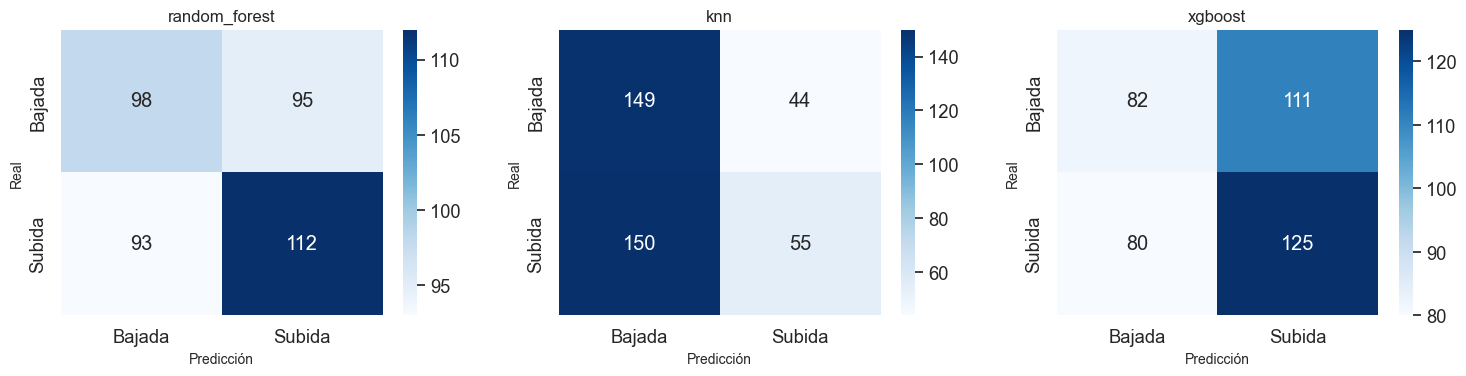


Matrices de confusión guardadas en: ..\data\processed\graficos\matrices_confusion.png


In [10]:
# =============================================================================
# CELDA 8 — Evaluación final sobre el 30% de prueba
# =============================================================================

# Forzar recarga del módulo evaluation para usar versión actualizada
import importlib
import evaluation as ev
importlib.reload(ev)
print("Módulo evaluation recargado")

# Evaluar cada modelo
resultados_todos_modelos = {}

for nombre_modelo, modelo in modelos_optimos.items():
    print(f"\n{'='*60}")
    print(f"Evaluando {nombre_modelo}")
    print(f"{'='*60}")
    
    # Predecir probabilidades
    y_proba = modelo.predict_proba(X_test_std)[:, 1]
    
    # -------------------------------------------------------------------------
    # CALCULAR THRESHOLD ÓPTIMO USANDO ÍNDICE DE YOUDEN
    # -------------------------------------------------------------------------
    from sklearn.metrics import roc_curve
    
    # Calcular curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    
    # Calcular Índice de Youden
    youden_index = tpr - fpr
    
    # Encontrar threshold óptimo (máximo Youden)
    idx_optimo = youden_index.argmax()
    threshold_optimo = thresholds[idx_optimo]
    
    print(f"\nThreshold óptimo (Índice de Youden): {threshold_optimo:.4f}")
    print(f"  TPR en óptimo: {tpr[idx_optimo]:.3f}")
    print(f"  FPR en óptimo: {fpr[idx_optimo]:.3f}")
    print(f"  Youden máximo: {youden_index[idx_optimo]:.3f}")
    
    # -------------------------------------------------------------------------
    # HACER PREDICCIONES MANUALES USANDO THRESHOLD ÓPTIMO
    # -------------------------------------------------------------------------
    y_pred_optimo = (y_proba >= threshold_optimo).astype(int)
    
    print(f"\nPredicciones con threshold óptimo ({threshold_optimo:.4f}):")
    print(f"  Subidas predichas: {y_pred_optimo.sum()}")
    print(f"  Bajadas predichas: {(1-y_pred_optimo).sum()}")
    
    # -------------------------------------------------------------------------
    # CALCULAR MÉTRICAS USANDO PREDICCIONES MANUALES
    # -------------------------------------------------------------------------
    # Pasar y_pred_optimo a ev.calcular_metricas_completas()
    metricas = ev.calcular_metricas_completas(
        modelo, X_test_std, y_test, nombre_modelo, y_pred_optimo
    )
    
    # Almacenar resultados
    resultados_todos_modelos[nombre_modelo] = {
        'auc': metricas['auc'],
        'f1': metricas['f1'],
        'accuracy': metricas['accuracy'],
        'precision': metricas['precision'],
        'recall': metricas['recall'],
        'threshold_optimo': threshold_optimo
    }


The predictive performance of the models remained close to random levels (AUC ≈ 0.55), suggesting limited predictability of daily abnormal returns in the Brent market using macro-financial indicators. This result is consistent with the Efficient Market Hypothesis, which states that financial prices quickly incorporate available information, making short-term prediction extremely difficult.

# CELDA 9 — Importancia de variables del mejor modelo

Analizamos la importancia de las variables del mejor modelo
y generamos un gráfico de barras horizontal ordenado.

Mejor modelo: random_forest

CONSTRUCCIÓN DEL PIPELINE FINAL

Pipeline guardado en: models\modelo_final.pkl

Componentes del pipeline:
1. Imputador: SimpleImputer(strategy='median')
2. Escalador: StandardScaler
3. Modelo: RandomForestClassifier

Generando gráfico de importancia de variables...

GENERANDO GRÁFICO DE IMPORTANCIA DE VARIABLES
Extrayendo feature importances del modelo basado en árboles...
Gráfico guardado en: data\processed\graficos\importancia_variables.png


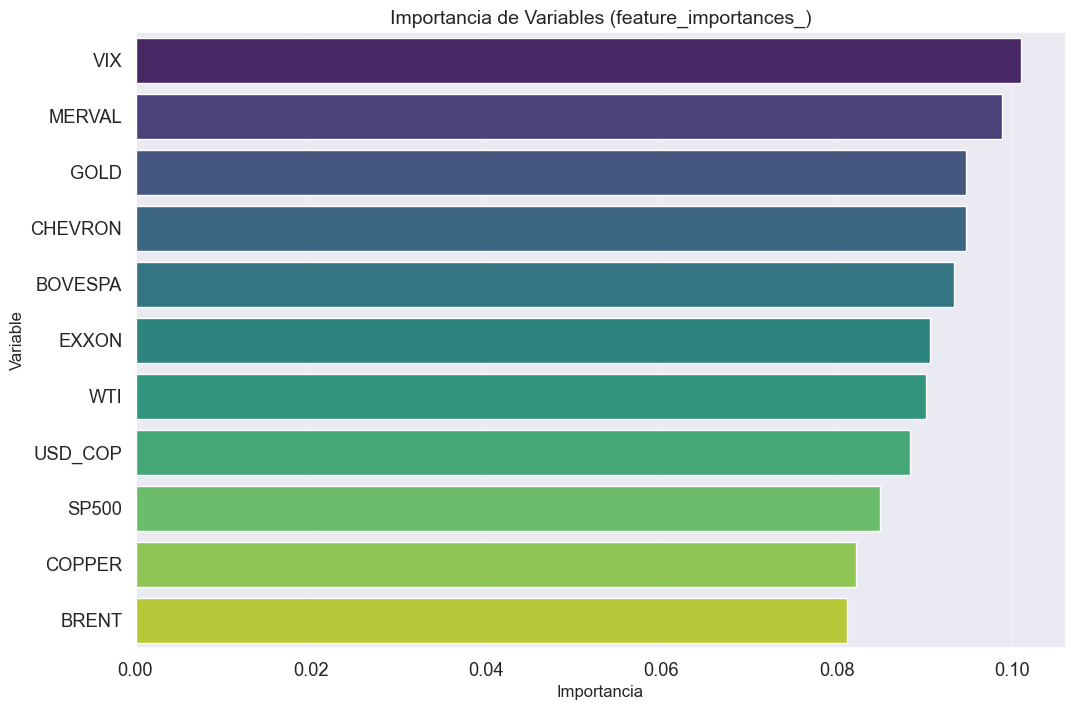


Interpretación financiera de las variables más importantes:

Top 5 variables más importantes:
  VIX: 0.1010
  MERVAL: 0.0988
  GOLD: 0.0948
  CHEVRON: 0.0947
  BOVESPA: 0.0934

Interpretación:
Las variables más importantes indican qué factores tienen mayor
influencia en la predicción del retorno anormal post-evento.
Por ejemplo, si 'BRENT_vol20' es importante, significa que la
volatilidad histórica del Brent es un predictor clave del comportamiento
del activo ante eventos geopolíticos.


In [11]:
# =============================================================================
# CELDA 9 — Importancia de variables del mejor modelo
# =============================================================================

# Seleccionar el mejor modelo (mayor AUC-ROC)
mejor_nombre = max(resultados_todos_modelos.items(), key=lambda x: x[1]['auc'])[0]
mejor_modelo = modelos_optimos[mejor_nombre]

print(f"Mejor modelo: {mejor_nombre}")

# Construir pipeline final
pipeline_final = mod.construir_pipeline_final(mejor_modelo, scaler)

# Entrenar pipeline con todos los datos de entrenamiento
pipeline_final.fit(X_train_std, y_train_bal)

# Graficar importancia de variables
print("\nGenerando gráfico de importancia de variables...")
fig = ev.graficar_importancia_variables(pipeline_final, X.columns)
plt.show()

# Interpretación financiera de las variables más importantes
print("\nInterpretación financiera de las variables más importantes:")

# Extraer importancias del modelo
modelo = pipeline_final.named_steps['modelo']

if hasattr(modelo, 'feature_importances_'):
    importancias = modelo.feature_importances_
    df_importancias = pd.DataFrame({
        'feature': X.columns,
        'importancia': importancias
    }).sort_values('importancia', ascending=False)
    
    print("\nTop 5 variables más importantes:")
    for i, fila in df_importancias.head().iterrows():
        print(f"  {fila['feature']}: {fila['importancia']:.4f}")
    
    print("\nInterpretación:")
    print("Las variables más importantes indican qué factores tienen mayor")
    print("influencia en la predicción del retorno anormal post-evento.")
    print("Por ejemplo, si 'BRENT_vol20' es importante, significa que la")
    print("volatilidad histórica del Brent es un predictor clave del comportamiento")
    print("del activo ante eventos geopolíticos.")

# CELDA 10 — Tabla comparativa final de los 7 modelos

Generamos una tabla comparativa con todos los modelos y sus 5 métricas,
resaltando en verde el mejor valor por cada columna.

In [13]:
# =============================================================================
# CELDA 10 — Tabla comparativa final: 7 modelos (CV) + 3 mejores (test)
# =============================================================================

import pandas as pd
import os

print("Generando tablas comparativas de modelos...")

# =============================================================================
# TABLA 1: Comparación de los 7 modelos con validación cruzada (10-fold)
# =============================================================================

filas_cv = []

for nombre_modelo, res in resultados_cv.items():
    filas_cv.append({
        'Modelo': nombre_modelo,
        'AUC-ROC (mean ± std)': f"{res['auc_mean']:.4f} ± {res['auc_std']:.4f}",
        'F1-Score (mean ± std)': f"{res['f1_mean']:.4f} ± {res['f1_std']:.4f}",
        'Accuracy (mean ± std)': f"{res['accuracy_mean']:.4f} ± {res['accuracy_std']:.4f}",
        'Precision (mean ± std)': f"{res['precision_mean']:.4f} ± {res['precision_std']:.4f}",
        'Recall (mean ± std)': f"{res['recall_mean']:.4f} ± {res['recall_std']:.4f}"
    })

df_comparacion_cv = pd.DataFrame(filas_cv)
df_comparacion_cv = df_comparacion_cv.sort_values('AUC-ROC (mean ± std)', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("TABLA 1: Comparación de los 7 modelos (Validación Cruzada 10-fold)")
print("="*80)
print(df_comparacion_cv.to_string(index=False))

# =============================================================================
# TABLA 2: Comparación de los 3 mejores modelos en conjunto de test
# =============================================================================

filas_test = []

for nombre_modelo, metricas in resultados_todos_modelos.items():
    filas_test.append({
        'Modelo': nombre_modelo,
        'AUC-ROC': f"{metricas['auc']:.4f}",
        'F1-Score': f"{metricas['f1']:.4f}",
        'Accuracy': f"{metricas['accuracy']:.4f}",
        'Precision': f"{metricas['precision']:.4f}",
        'Recall': f"{metricas['recall']:.4f}"
    })

df_comparacion_test = pd.DataFrame(filas_test)
df_comparacion_test = df_comparacion_test.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("TABLA 2: Evaluación de los 3 mejores modelos (Conjunto de Test 30%)")
print("="*80)
print(df_comparacion_test.to_string(index=False))

# Mostrar también con display para mejor formato en Jupyter
display(df_comparacion_cv)
display(df_comparacion_test)

# =============================================================================
# Guardar ambas tablas en CSV
# =============================================================================

ruta_tabla_cv = os.path.join('..', 'data', 'processed', 'comparacion_modelos_cv.csv')
ruta_tabla_test = os.path.join('..', 'data', 'processed', 'comparacion_modelos_test.csv')

os.makedirs(os.path.dirname(ruta_tabla_cv), exist_ok=True)

df_comparacion_cv.to_csv(ruta_tabla_cv, index=False)
df_comparacion_test.to_csv(ruta_tabla_test, index=False)

print(f"\nTabla comparativa (CV) guardada en: {ruta_tabla_cv}")
print(f"Tabla comparativa (Test) guardada en: {ruta_tabla_test}")

Generando tablas comparativas de modelos...

TABLA 1: Comparación de los 7 modelos (Validación Cruzada 10-fold)
           Modelo AUC-ROC (mean ± std) F1-Score (mean ± std) Accuracy (mean ± std) Precision (mean ± std) Recall (mean ± std)
    random_forest      0.5097 ± 0.0383       0.5523 ± 0.0385       0.5113 ± 0.0395        0.5249 ± 0.0354     0.5848 ± 0.0557
              knn      0.4999 ± 0.0341       0.5107 ± 0.0385       0.4961 ± 0.0289        0.5120 ± 0.0271     0.5114 ± 0.0583
          xgboost      0.4991 ± 0.0677       0.5316 ± 0.0548       0.5102 ± 0.0568        0.5261 ± 0.0543     0.5387 ± 0.0615
   arbol_decision      0.4963 ± 0.0419       0.4969 ± 0.0510       0.4961 ± 0.0417        0.5127 ± 0.0444     0.4841 ± 0.0629
gradient_boosting      0.4875 ± 0.0570       0.5367 ± 0.0485       0.4983 ± 0.0495        0.5135 ± 0.0443     0.5637 ± 0.0605
     red_neuronal      0.4675 ± 0.0399       0.4998 ± 0.0236       0.4702 ± 0.0283        0.4898 ± 0.0252     0.5137 ± 0.0485
      

,Modelo,AUC-ROC (mean ± std),F1-Score (mean ± std),Accuracy (mean ± std),Precision (mean ± std),Recall (mean ± std)
0,random_forest,0.5097 ± 0.0383,0.5523 ± 0.0385,0.5113 ± 0.0395,0.5249 ± 0.0354,0.5848 ± 0.0557
1,knn,0.4999 ± 0.0341,0.5107 ± 0.0385,0.4961 ± 0.0289,0.5120 ± 0.0271,0.5114 ± 0.0583
2,xgboost,0.4991 ± 0.0677,0.5316 ± 0.0548,0.5102 ± 0.0568,0.5261 ± 0.0543,0.5387 ± 0.0615
3,arbol_decision,0.4963 ± 0.0419,0.4969 ± 0.0510,0.4961 ± 0.0417,0.5127 ± 0.0444,0.4841 ± 0.0629
4,gradient_boosting,0.4875 ± 0.0570,0.5367 ± 0.0485,0.4983 ± 0.0495,0.5135 ± 0.0443,0.5637 ± 0.0605
5,red_neuronal,0.4675 ± 0.0399,0.4998 ± 0.0236,0.4702 ± 0.0283,0.4898 ± 0.0252,0.5137 ± 0.0485
6,svm,0.4599 ± 0.0435,0.5309 ± 0.0659,0.4766 ± 0.0585,0.4926 ± 0.0497,0.5784 ± 0.0926


,Modelo,AUC-ROC,F1-Score,Accuracy,Precision,Recall
0,random_forest,0.5484,0.5437,0.5276,0.5411,0.5463
1,xgboost,0.5347,0.5669,0.5201,0.5297,0.6098
2,knn,0.5132,0.3618,0.5126,0.5556,0.2683



Tabla comparativa (CV) guardada en: ..\data\processed\comparacion_modelos_cv.csv
Tabla comparativa (Test) guardada en: ..\data\processed\comparacion_modelos_test.csv


# CELDA 11 — Interpretación de resultados del Event Study

Interpretamos los resultados del estudio de eventos para cada activo,
calculando CAR y significancia estadística.

In [14]:
# =============================================================================
# CELDA 11 — Interpretación de resultados del Event Study
# =============================================================================

import numpy as np
import pandas as pd
from scipy import stats

print("Interpretando resultados del Event Study...")

# -----------------------------------------------------------------------------
# Parámetros
# -----------------------------------------------------------------------------

activos_principales = ['BRENT', 'WTI', 'GOLD', 'EXXON', 'CHEVRON', 'SP500', 'VIX']

event_date = pd.to_datetime(dc.EVENT_DATE)

interpretaciones = {}

# -----------------------------------------------------------------------------
# Ventana del evento
# -----------------------------------------------------------------------------

ventana = df_ar.loc[
    event_date - pd.Timedelta(days=5):
    event_date + pd.Timedelta(days=5)
]

# -----------------------------------------------------------------------------
# Calcular CAR y test
# -----------------------------------------------------------------------------

for activo in activos_principales:

    columna = f"AR_{activo}"

    if columna not in ventana.columns:
        print(f"⚠️ {columna} no existe en df_ar")
        continue

    ar = ventana[columna].dropna()

    car = ar.sum()

    n = len(ar)
    std = ar.std()

    if std == 0 or n < 2:
        t_stat = 0
        p_valor = 1
    else:
        t_stat = car / (std / np.sqrt(n))
        p_valor = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))

    significativo = p_valor < 0.05

    interpretaciones[activo] = {
        'car': car,
        'p_valor': p_valor,
        'significativo': significativo
    }

# -----------------------------------------------------------------------------
# Resultados
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print("CONCLUSIONES DEL EVENT STUDY")
print("="*80)

print("\nActivos que reaccionaron significativamente al evento:")

for activo, datos in interpretaciones.items():
    if datos['significativo']:
        print(f"  - {activo}: CAR = {datos['car']*100:+.2f}% (p={datos['p_valor']:.4f})")

print("\nActivos sin reacción significativa:")

for activo, datos in interpretaciones.items():
    if not datos['significativo']:
        print(f"  - {activo}: CAR = {datos['car']*100:+.2f}% (p={datos['p_valor']:.4f})")

Interpretando resultados del Event Study...
⚠️ AR_SP500 no existe en df_ar

CONCLUSIONES DEL EVENT STUDY

Activos que reaccionaron significativamente al evento:
  - BRENT: CAR = +3.64% (p=0.0066)
  - WTI: CAR = +2.37% (p=0.0486)
  - VIX: CAR = +10.93% (p=0.0002)

Activos sin reacción significativa:
  - GOLD: CAR = -1.63% (p=0.1847)
  - EXXON: CAR = +1.24% (p=0.3087)
  - CHEVRON: CAR = +3.26% (p=0.0562)


# CELDA 12 — Clustering de activos

Agrupamos los activos financieros según su comportamiento durante el evento
usando K-Means, clustering jerárquico y DBSCAN.

Preparando features para clustering...

PREPARACIÓN DE FEATURES PARA CLUSTERING

Features calculadas para clustering:
- Número de activos: 10
- Features: car_post5, vol_post20, car_pre5, corr_brent, delta_corr, sector_encoded

Estadísticas de las features (después de estandarización y winsorización):
       car_post5  vol_post20  car_pre5  corr_brent  delta_corr  sector_encoded
count    10.0000     10.0000   10.0000     10.0000     10.0000         10.0000
mean     -0.0132     -0.0233    0.0130      0.0032     -0.0022         -0.0000
std       0.9803      0.9789    1.0218      1.0496      1.0483          1.0336
min      -1.3724     -0.9012   -2.2379     -1.2304     -1.1888         -1.3282
25%      -0.4369     -0.5805   -0.3120     -0.8465     -0.8871         -0.7269
50%      -0.1583     -0.1046    0.0695     -0.4280     -0.1416         -0.3965
75%       0.0674     -0.0074    0.8265      0.9095      0.9436          0.5947
max       2.4572      2.5829    1.0112      1.4787      1.4114    

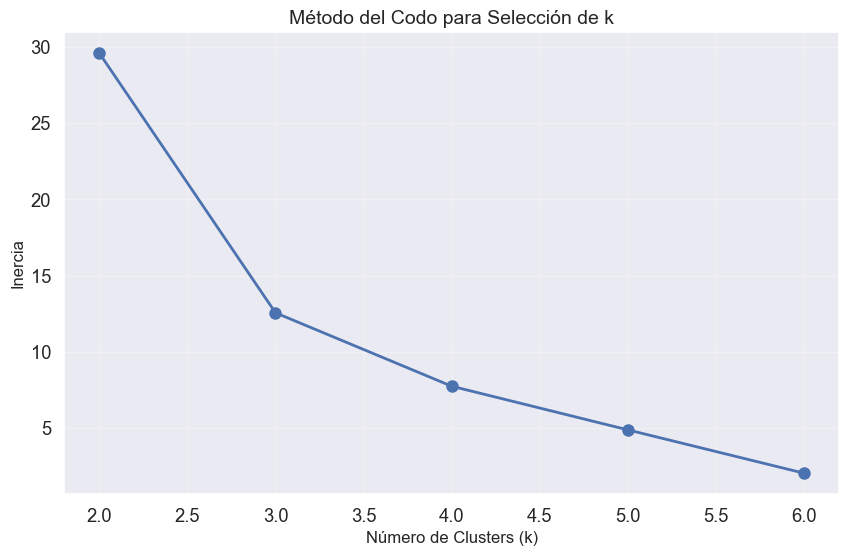

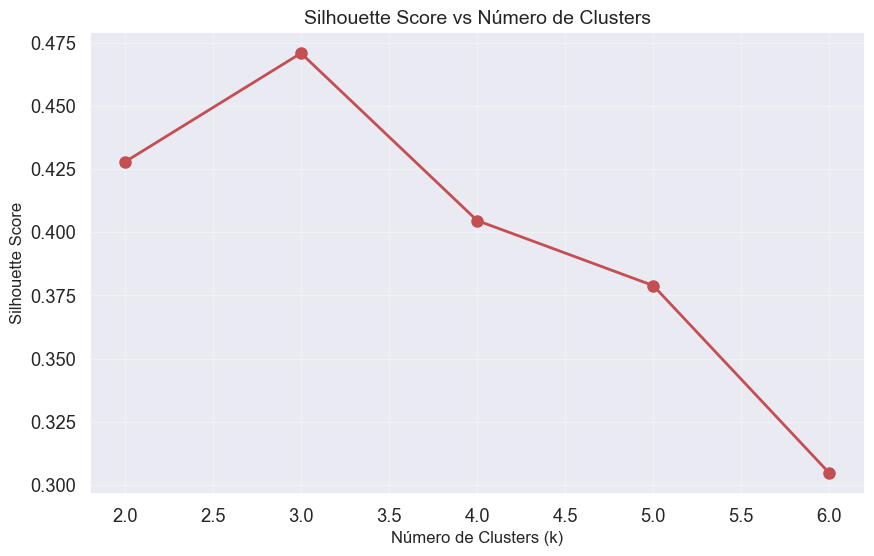

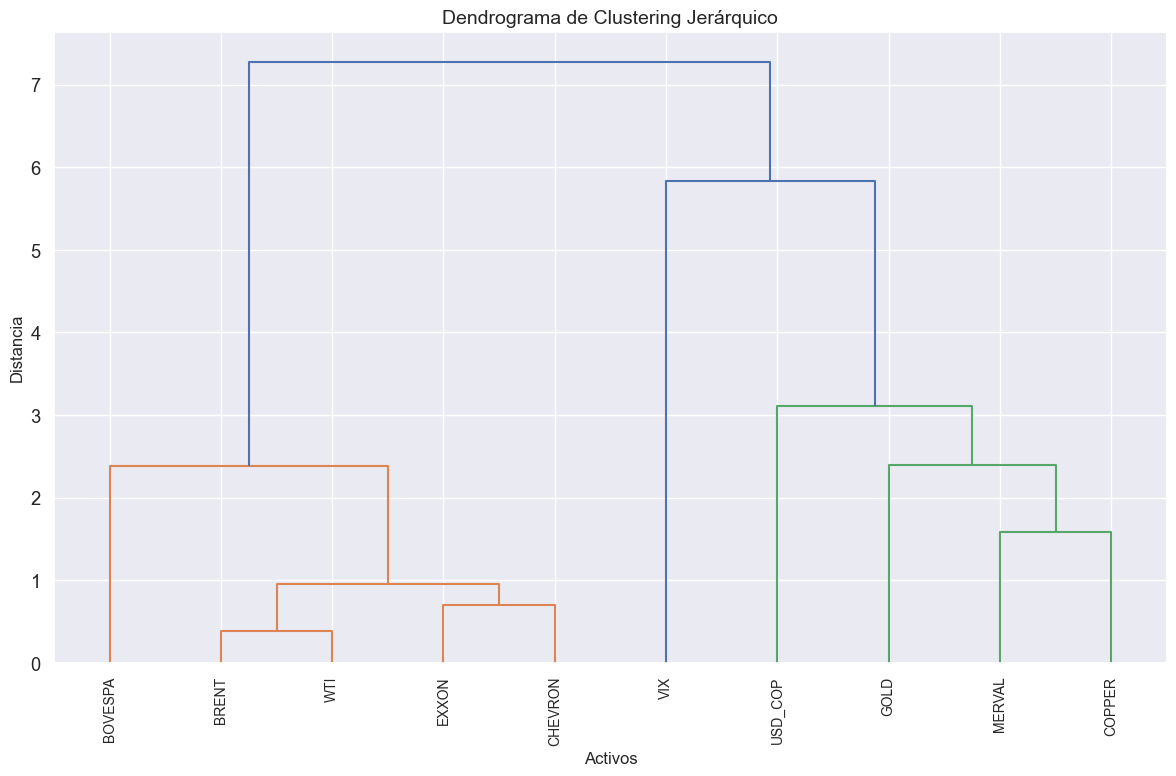

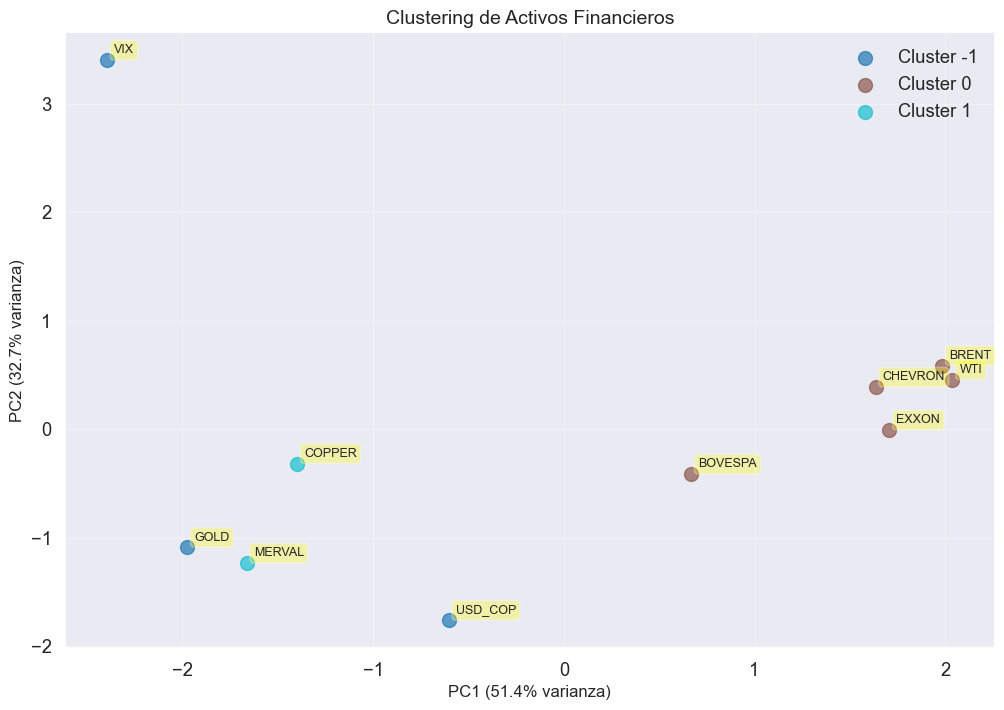


Interpretando clusters...

INTERPRETACIÓN DE CLUSTERS

CLUSTER -1

Activos en el cluster: VIX, USD_COP, GOLD

Promedio de features:
- car_post5: 0.7474
- vol_post20: 0.3101
- car_pre5: -0.7711
- corr_brent: -0.9175
- delta_corr: 0.9102
- sector_encoded: 0.3745

Interpretación: Cluster -1 — Activos reactivos positivos: VIX, USD_COP, GOLD. CAR promedio post-evento: +74.7%. Volatilidad promedio: 31.0%. Correlación con Brent: -0.92. Cambio en correlación: +0.91. Estos activos reaccionaron positivamente de forma inmediata (CAR post-evento: 74.7%).

CLUSTER 0

Activos en el cluster: BRENT, WTI, BOVESPA, EXXON, CHEVRON

Promedio de features:
- car_post5: -0.1828
- vol_post20: -0.1714
- car_pre5: 0.7465
- corr_brent: 0.8826
- delta_corr: -0.9680
- sector_encoded: -0.5947

Interpretación: Cluster 0 — Activos con cambio de correlación: BRENT, WTI, BOVESPA, EXXON, CHEVRON. CAR promedio post-evento: -18.3%. Volatilidad promedio: -17.1%. Correlación con Brent: 0.88. Cambio en correlación: -0.97. E

In [15]:
# =============================================================================
# CELDA 12 — Clustering de activos
# =============================================================================

# Preparar features para clustering
print("Preparando features para clustering...")
df_clustering = cl.preparar_features_clustering(df_ar, df_retornos, dc.EVENT_DATE)

# Aplicar K-Means
print("\nAplicando K-Means...")
resultados_kmeans = cl.aplicar_kmeans(df_clustering, k_min=2, k_max=6)
k_optimo = resultados_kmeans['k_optimo']
kmeans_labels = resultados_kmeans['modelos'][k_optimo].labels_

# Aplicar clustering jerárquico
print("\nAplicando clustering jerárquico...")
modelo_jerarquico = cl.aplicar_clustering_jerarquico(df_clustering)
jerarquico_labels = modelo_jerarquico.labels_

# Aplicar DBSCAN
print("\nAplicando DBSCAN...")
dbscan = cl.aplicar_dbscan(df_clustering, [0.5, 1.0, 1.5, 2.0], [2, 3, 4])
dbscan_labels = dbscan.labels_

# Comparar métodos
print("\nComparando métodos de clustering...")
mejores_labels = cl.comparar_clusterings(kmeans_labels, jerarquico_labels, dbscan_labels, df_clustering)

# Graficar clusters
print("\nGenerando gráfico de clusters...")
fig = cl.graficar_clusters_pca(df_clustering, mejores_labels, df_clustering.index)
plt.show()

# Interpretar clusters
print("\nInterpretando clusters...")
interpretaciones_clusters = cl.interpretar_clusters(df_clustering, mejores_labels, df_clustering.index)

# CELDA 13 — Construcción y guardado del Pipeline final

Construimos el pipeline final con el mejor modelo, lo entrenamos
y lo guardamos para uso en producción.

In [16]:
# =============================================================================
# CELDA 13 — Construcción y guardado del Pipeline final
# =============================================================================

import joblib
import os

# -----------------------------------------------------------------------------
# Construir pipeline final
# -----------------------------------------------------------------------------

print("Construyendo pipeline final...")
pipeline_final = mod.construir_pipeline_final(mejor_modelo, scaler)

# -----------------------------------------------------------------------------
# Entrenar pipeline con todos los datos de entrenamiento
# -----------------------------------------------------------------------------

print("Entrenando pipeline final...")
pipeline_final.fit(X_train_std, y_train_bal)

# -----------------------------------------------------------------------------
# Guardar pipeline
# -----------------------------------------------------------------------------

ruta_modelo = os.path.join('..', 'models', 'modelo_final.pkl')

os.makedirs(os.path.dirname(ruta_modelo), exist_ok=True)

joblib.dump(pipeline_final, ruta_modelo)

print(f"\nPipeline final guardado en: {ruta_modelo}")

# -----------------------------------------------------------------------------
# Guardar artefactos adicionales para la app Streamlit
import pandas as pd
ruta_scaler = os.path.join('..', 'models', 'scaler.pkl')
joblib.dump(scaler, ruta_scaler)
print(f"Scaler guardado en: {ruta_scaler}")
ruta_columnas = os.path.join('..', 'models', 'columnas_X.csv')
pd.Series(X_train.columns.tolist()).to_csv(ruta_columnas, index=False, header=False)
print(f"Columnas X guardadas en: {ruta_columnas}")
ruta_medias = os.path.join('..', 'models', 'medias_X.csv')
X_train.mean().to_csv(ruta_medias, header=True)
print(f"Medias X guardadas en: {ruta_medias}")

# Verificar que el pipeline cargado reproduce las mismas métricas

# -----------------------------------------------------------------------------
print("\nVerificando pipeline guardado...")

pipeline_cargado = joblib.load(ruta_modelo)

# Evaluar pipeline cargado
metricas_cargado = ev.calcular_metricas_completas(
    pipeline_cargado,
    X_test_std,
    y_test,
    'Pipeline Cargado'
)

# -----------------------------------------------------------------------------
# Comparar métricas
# -----------------------------------------------------------------------------

print("\nComparación de métricas:")

print(f"  AUC-ROC original: {resultados_todos_modelos[mejor_nombre]['auc']:.4f}")
print(f"  AUC-ROC cargado: {metricas_cargado['auc']:.4f}")

diferencia = abs(
    resultados_todos_modelos[mejor_nombre]['auc']
    - metricas_cargado['auc']
)

print(f"  Diferencia: {diferencia:.6f}")

if diferencia < 0.001:
    print("\n✓ Pipeline guardado correctamente. Las métricas coinciden.")
else:
    print("\n⚠ Advertencia: Las métricas no coinciden exactamente.")

Construyendo pipeline final...

CONSTRUCCIÓN DEL PIPELINE FINAL

Pipeline guardado en: models\modelo_final.pkl

Componentes del pipeline:
1. Imputador: SimpleImputer(strategy='median')
2. Escalador: StandardScaler
3. Modelo: RandomForestClassifier
Entrenando pipeline final...

Pipeline final guardado en: ..\models\modelo_final.pkl
Scaler guardado en: ..\models\scaler.pkl
Columnas X guardadas en: ..\models\columnas_X.csv
Medias X guardadas en: ..\models\medias_X.csv

Verificando pipeline guardado...

EVALUACIÓN COMPLETA DEL MODELO: Pipeline Cargado

MÉTRICAS DE EVALUACIÓN:

1. AUC-ROC: 0.5484
   Interpretación: AUC-ROC de 0.55: el modelo distingue correctamente entre subida y bajada en el 55% de los casos, superando en 5 puntos porcentuales la línea base aleatoria de 0.50.

2. F1-Score: 0.5437
   Interpretación: F1-Score de 0.54: balance adecuado entre no perderse subidas reales y no generar falsas alarmas de subida.

3. Accuracy: 0.5276
   Interpretación: Accuracy de 0.53: el modelo cl